# Exploratory Data Analysis — Wine Dataset

This notebook provides a focused exploratory data analysis (EDA) for the cleaned wine quality dataset.
Each section contains a short explanation followed by a code cell that produces charts using Matplotlib (no seaborn).

Notes: adjust the `path` variable in the first code cell if your CSV is located elsewhere.

## 1 — Load dataset and quick overview
We load the CSV into a `DataFrame`, display the first rows, data types, and basic descriptive statistics.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Update this path if needed (relative to this notebook)
path = 'datasets/wine+quality/winequality-red-edited.csv'
df = pd.read_csv(path)

# Quick overview
print('Shape:', df.shape)
display(df.head())
print('Info:')
print(df.info())

print('Descriptive statistics:')
display(df.describe())

Shape: (1359, 12)


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,3
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,3
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,3
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,4
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,3


Info:
<class 'pandas.DataFrame'>
RangeIndex: 1359 entries, 0 to 1358
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         1359 non-null   float64
 1   volatile_acidity      1359 non-null   float64
 2   citric_acid           1359 non-null   float64
 3   residual_sugar        1359 non-null   float64
 4   chlorides             1359 non-null   float64
 5   free_sulfur_dioxide   1359 non-null   float64
 6   total_sulfur_dioxide  1359 non-null   float64
 7   density               1359 non-null   float64
 8   pH                    1359 non-null   float64
 9   sulphates             1359 non-null   float64
 10  alcohol               1359 non-null   float64
 11  quality               1359 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 127.5 KB
None
Descriptive statistics:


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
count,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000
mean,8.310596,0.529478,0.272333,2.523400,0.088124,15.893304,46.825975,0.996709,3.309787,0.658705,10.432315,3.623252
std,1.736990,0.183031,0.195537,1.352314,0.049377,10.447270,33.408946,0.001869,0.155036,0.170667,1.082065,0.823578
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,1.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,3.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996700,3.310000,0.620000,10.200000,4.000000
75%,9.200000,0.640000,0.430000,2.600000,0.091000,21.000000,63.000000,0.997820,3.400000,0.730000,11.100000,4.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,6.000000


## 2 — Missing values and basic checks
Check for missing data and duplicated rows.

In [8]:
# Missing values and duplicates
missing = df.isnull().sum()
print('Missing values per column:', missing)
print('Total duplicates:', df.duplicated().sum())

Missing values per column: fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64
Total duplicates: 0


## 3 — Distribution of numerical features (histograms)
Plot histograms for all numeric columns to inspect distributions and skewness.

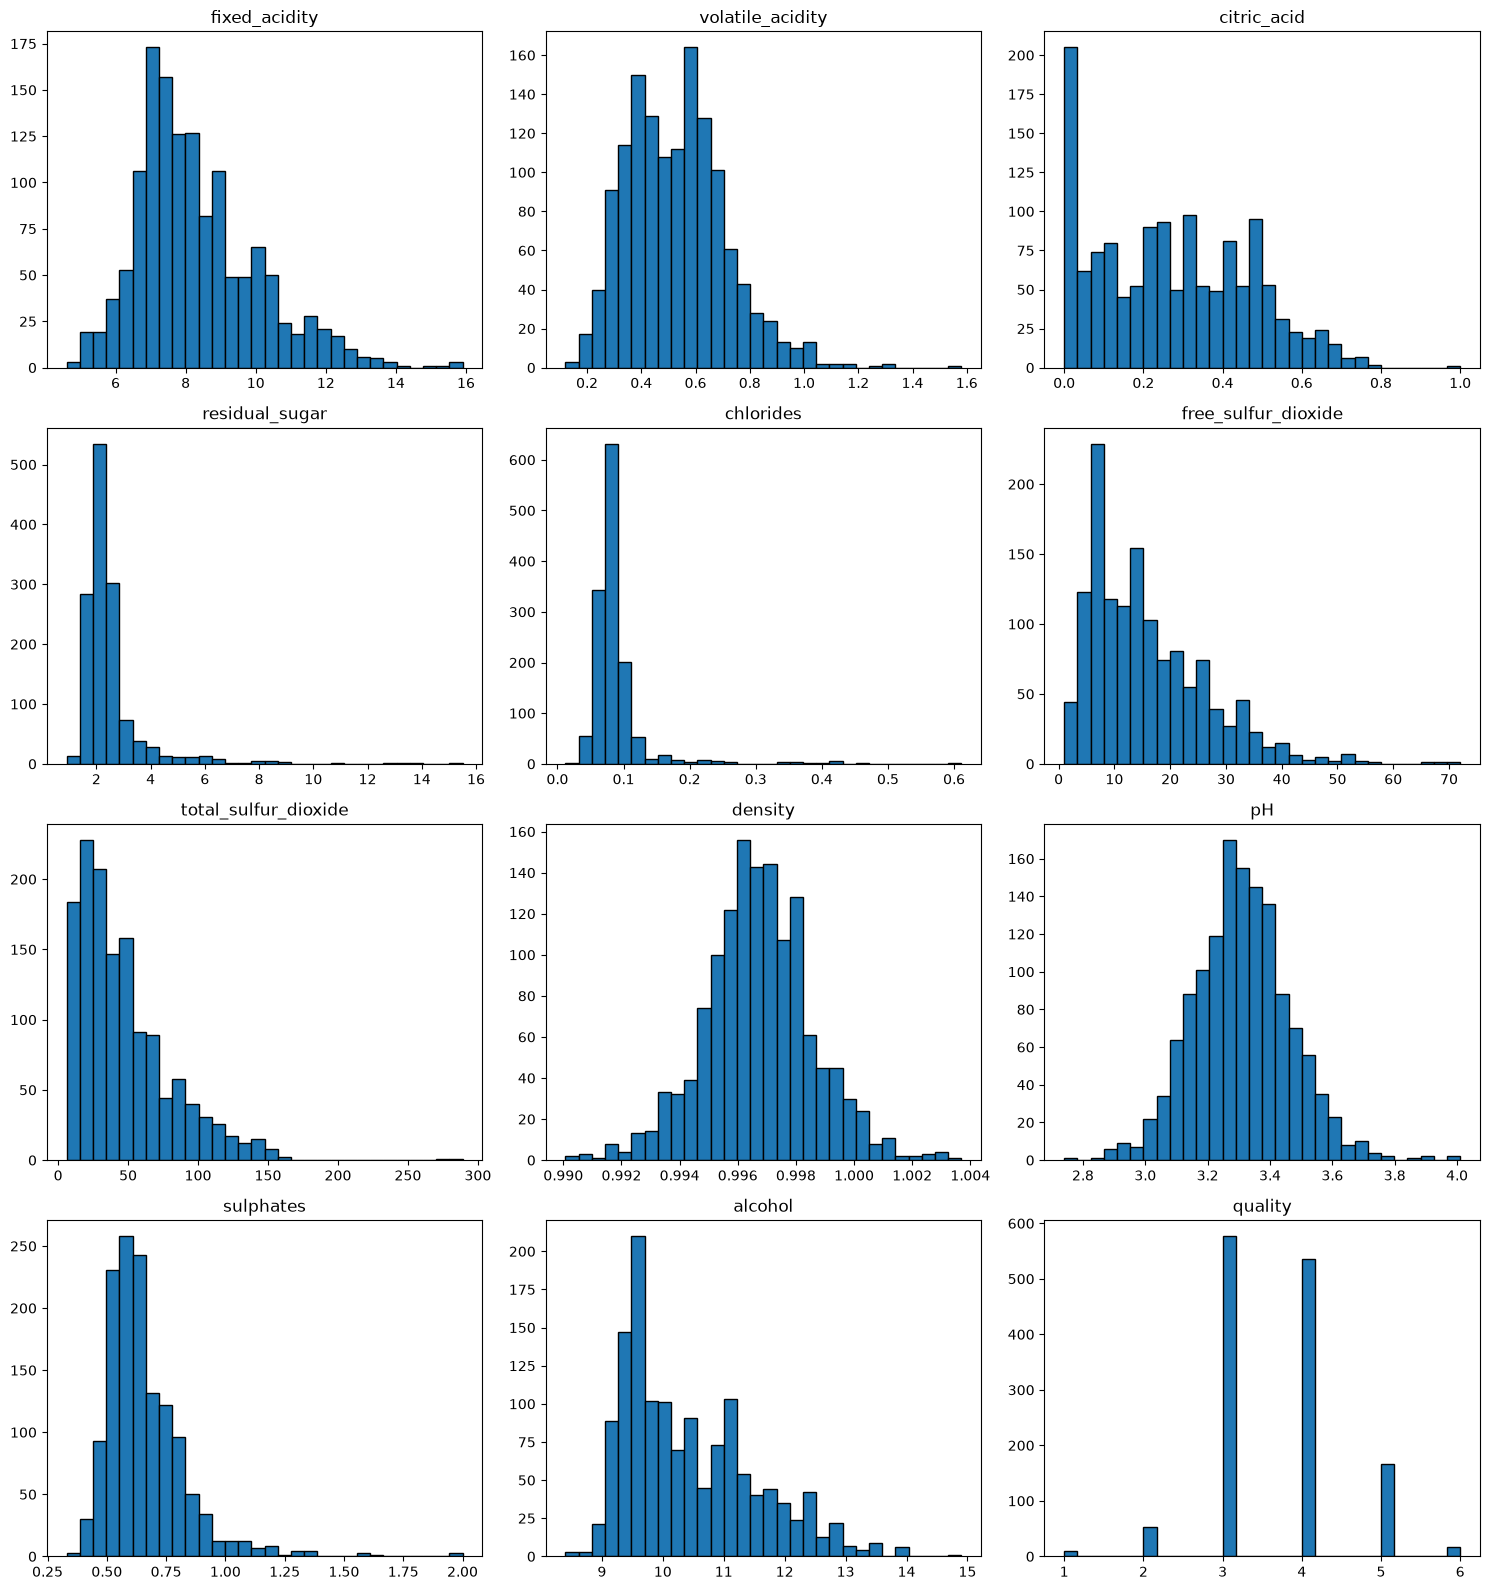

In [9]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
n = len(num_cols)
cols_per_row = 3
rows = (n + cols_per_row - 1) // cols_per_row
fig, axes = plt.subplots(rows, cols_per_row, figsize=(5*cols_per_row, 4*rows))
axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=30, color='tab:blue', edgecolor='black')
    axes[i].set_title(col)
    axes[i].grid(False)
# Hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].axis('off')
fig.tight_layout()
plt.show()

## 4 — Boxplots to highlight outliers
Boxplots summarize spread and reveal extreme values. We plot one boxplot per numeric feature.

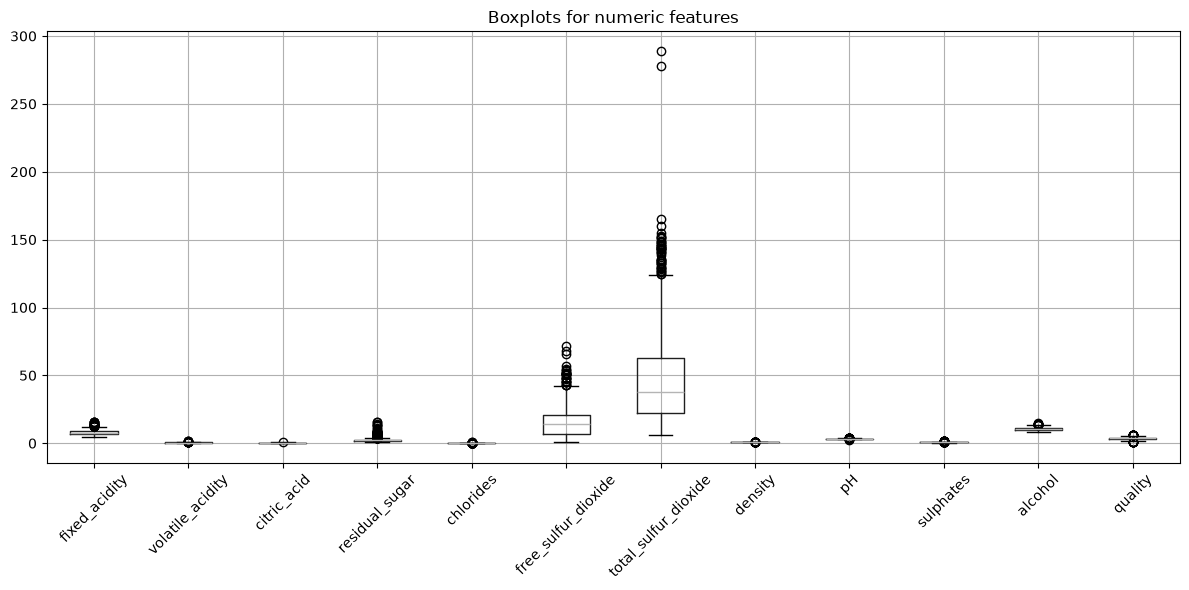

In [10]:
fig, ax = plt.subplots(figsize=(12,6))
df[num_cols].boxplot(rot=45, ax=ax)
ax.set_title('Boxplots for numeric features')
plt.tight_layout()
plt.show()

## 5 — Quality counts (bar chart)
Show how many wines have each quality score. Useful for class imbalance checks.

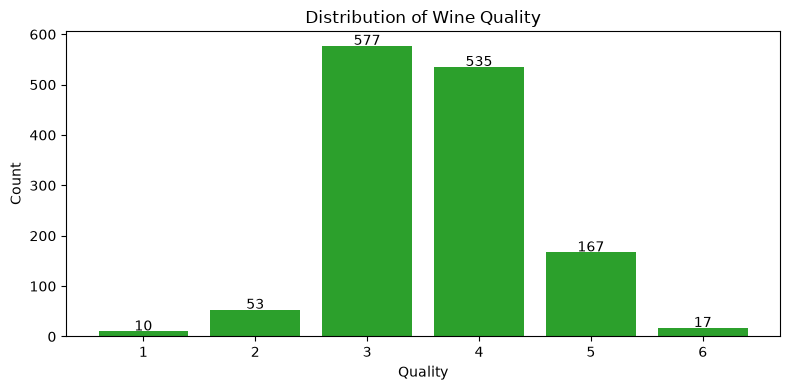

In [11]:
qc = df['quality'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8,4))
ax.bar(qc.index.astype(str), qc.values, color='tab:green')
ax.set_xlabel('Quality')
ax.set_ylabel('Count')
ax.set_title('Distribution of Wine Quality')
for i, v in enumerate(qc.values):
    ax.text(i, v+2, str(v), ha='center')
plt.tight_layout()
plt.show()

## 6 — Scatter plots (example relationships)
Scatter plots between `alcohol` and `quality`, and between `volatile acidity` and `quality`.

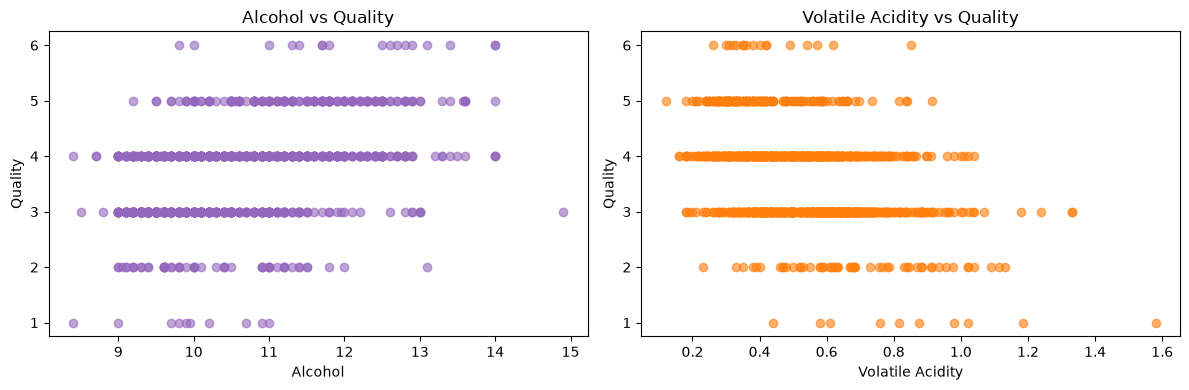

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].scatter(df['alcohol'], df['quality'], alpha=0.6, color='tab:purple')
axes[0].set_xlabel('Alcohol')
axes[0].set_ylabel('Quality')
axes[0].set_title('Alcohol vs Quality')
axes[1].scatter(df['volatile_acidity'], df['quality'], alpha=0.6, color='tab:orange')
axes[1].set_xlabel('Volatile Acidity')
axes[1].set_ylabel('Quality')
axes[1].set_title('Volatile Acidity vs Quality')
plt.tight_layout()
plt.show()

## 7 — Correlation matrix (heatmap with Matplotlib)
Compute Pearson correlations and visualize with `imshow`. This highlights strong linear relationships.

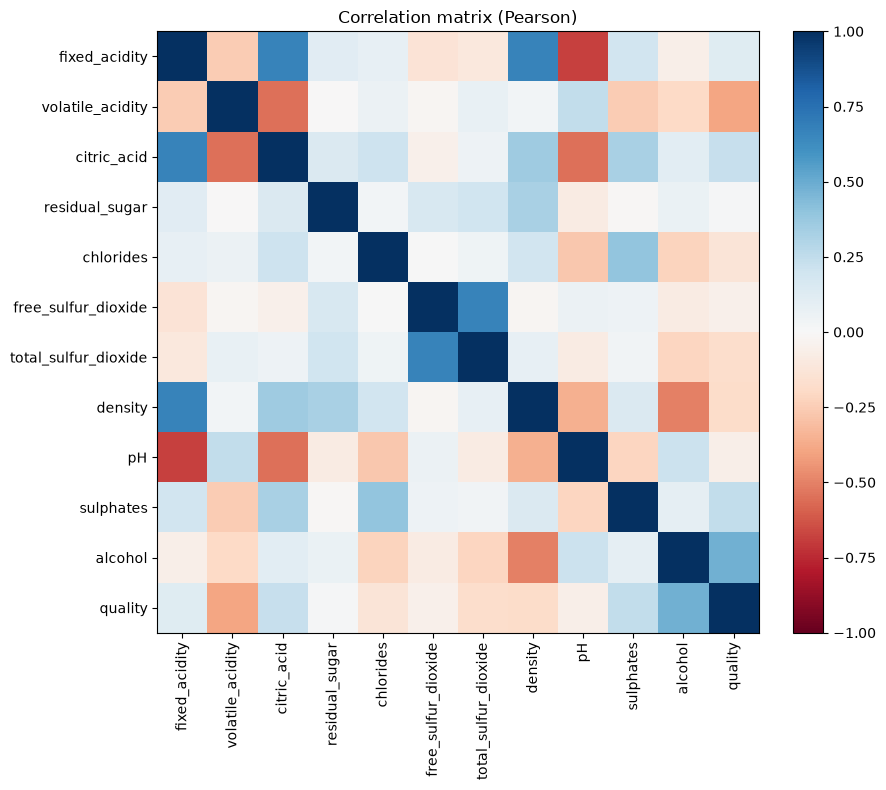

In [13]:
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(10,8))
cax = ax.imshow(corr, cmap='RdBu', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.index)
fig.colorbar(cax, ax=ax, fraction=0.046, pad=0.04)
ax.set_title('Correlation matrix (Pearson)')
plt.tight_layout()
plt.show()

## Next steps / Suggestions
- Use log-transforms on highly skewed features before modeling.
- Consider binning `quality` for classification tasks (e.g., low/medium/high).
- Explore partial dependence or feature importance with a simple model to confirm visual findings.